In [32]:
import zstandard as zstd
import chess.pgn
import io
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [22]:
# --- CONFIGURACIÓN DE RUTAS ---
input_file = "../data/lichess_db_standard_rated_2019-01.pgn.zst"

out_train = "../data/generado/noleak/train.pgn"
out_val   = "../data/generado/noleak/val.pgn"
out_test  = "../data/generado/noleak/test.pgn"

# Queremos 100,000 partidas EN TOTAL repartidas. 
# Como al limpiar cruces vamos a descartar muchas, necesitamos leer más en la Pasada 1.
MAX_GAMES_TARGET = 100000
POOL_SIZE = MAX_GAMES_TARGET * 4  # Extraemos 400k encabezados para asegurar suficientes limpias

In [23]:
def parse_time_control(tc):
    try:
        return int(tc.split("+")[0])
    except:
        return 0

In [24]:
def partida_valida(headers):
    """
    Corrobora que los jugadores tengan más de 900
    de elo y que la partida dure más de 180 segundos
    """
    try:
        white_elo = int(headers.get("WhiteElo", 0))
        black_elo = int(headers.get("BlackElo", 0))
        time_control = headers.get("TimeControl", "")

        if white_elo < 900 or black_elo < 900:
            return False

        base_seconds = parse_time_control(time_control)
        if base_seconds < 180:
            return False

        return True
    except:
        return False


### PASADA 1: Recopilar metadatos de jugadores

In [ ]:
"""
Leemos solo los metadatos (encabezados) de las partidas usando chess.pgn.read_headers(). 
Esto es más rapido porque no procesa los movimientos. Guardamos los nombres y el Elo de los
jugadores en memoria hasta tener un "pool" lo suficientemente grande.
"""

print("Iniciando Pasada 1: Recopilación rápida de jugadores...")
metadata = []

with open(input_file, "rb") as compressed:
    dctx = zstd.ZstdDecompressor()
    with dctx.stream_reader(compressed) as reader:
        text_stream = io.TextIOWrapper(reader, encoding="utf-8")
        
        while len(metadata) < POOL_SIZE:
            # read_headers es muchísimo más rápido que read_game
            headers = chess.pgn.read_headers(text_stream)
            if headers is None:
                break
            
            if partida_valida(headers):
                metadata.append({
                    'White': headers.get("White"),
                    'Black': headers.get("Black"),
                    'WhiteElo': int(headers.get("WhiteElo", 0)),
                    'BlackElo': int(headers.get("BlackElo", 0))
                })
                
                if len(metadata) % 50000 == 0:
                    print(f"  Recopilados {len(metadata)} encabezados...")

print("Pasada 1 completada.")

Iniciando Pasada 1: Recopilación rápida de jugadores...
  Recopilados 50000 encabezados...
  Recopilados 100000 encabezados...
  Recopilados 150000 encabezados...
  Recopilados 200000 encabezados...
  Recopilados 250000 encabezados...
  Recopilados 300000 encabezados...
  Recopilados 350000 encabezados...
  Recopilados 400000 encabezados...
Pasada 1 completada.


### PASO INTERMEDIO: Algoritmo de partición

In [ ]:
df = pd.DataFrame(metadata)

# Obtener jugadores únicos y su elo promedio
white_players = df[['White', 'WhiteElo']].rename(columns={'White': 'Player', 'WhiteElo': 'Elo'})
black_players = df[['Black', 'BlackElo']].rename(columns={'Black': 'Player', 'BlackElo': 'Elo'})
player_elo = pd.concat([white_players, black_players]).groupby('Player')['Elo'].mean().reset_index()

# Estratificación por rangos de Elo (de 100 en 100)
player_elo['EloBin'] = pd.cut(player_elo['Elo'], bins=range(800, 3200, 100), labels=False)
player_elo = player_elo.dropna(subset=['EloBin'])

# Contamos cuántos jugadores hay en cada 'bin'
bin_counts = player_elo['EloBin'].value_counts()
# Nos quedamos solo con los bins que tengan al menos 5 jugadores (suficientes para dividir 70/15/15)
valid_bins = bin_counts[bin_counts >= 6].index
player_elo = player_elo[player_elo['EloBin'].isin(valid_bins)]

# Split (52% Train, 24% Val, 24% Test), luego 0.52*0.52 = 0.27, 0.24*0.24=0.057 entonces 0.27/(0.27+0.057+0.057)= 0.70 => 70%
train_players, temp_players = train_test_split(player_elo, test_size=0.48, stratify=player_elo['EloBin'], random_state=42)
val_players, test_players = train_test_split(temp_players, test_size=0.50, stratify=temp_players['EloBin'], random_state=42)

# Convertir a sets para búsqueda ultra rápida O(1)
train_set = set(train_players['Player'])
val_set = set(val_players['Player'])
test_set = set(test_players['Player'])

print(f"Jugadores únicos válidos: {len(player_elo)}")
print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

Jugadores únicos válidos: 125208
Train: 65108 | Val: 30050 | Test: 30050


###  PASADA 2: Guardar las partidas limpias

In [ ]:
"""
Volvemos a abrir el archivo, leemos la partida completa con chess.pgn.read_game(), miramos en nuestros
sets a dónde pertenecen los jugadores, y escribimos la partida en el archivo PGN correspondiente 
(train.pgn, val.pgn o test.pgn) hasta llegar a tu meta de 100,000 partidas limpias.
"""

print("Iniciando Pasada 2: Extrayendo y guardando partidas completas...")

counts = {'train': 0, 'val': 0, 'test': 0, 'discarded': 0}

with open(input_file, "rb") as compressed, \
     open(out_train, "w", encoding="utf-8") as f_train, \
     open(out_val, "w", encoding="utf-8") as f_val, \
     open(out_test, "w", encoding="utf-8") as f_test:

    dctx = zstd.ZstdDecompressor()
    with dctx.stream_reader(compressed) as reader:
        text_stream = io.TextIOWrapper(reader, encoding="utf-8")
        
        # Leemos hasta alcanzar nuestro objetivo (ej. 70k train, 15k val, 15k test)
        # O hasta llegar a MAX_GAMES_TARGET en general
        total_guardadas = 0
        
        while total_guardadas < MAX_GAMES_TARGET:
            game = chess.pgn.read_game(text_stream)
            if game is None:
                break
                
            headers = game.headers
            if not partida_valida(headers):
                continue
                
            w_player = headers.get("White")
            b_player = headers.get("Black")
            
            # Verificar si pertenece a algún set válido sin cruces
            if w_player in train_set and b_player in train_set:
                f_train.write(str(game) + "\n\n")
                counts['train'] += 1
                total_guardadas += 1
            elif w_player in val_set and b_player in val_set:
                f_val.write(str(game) + "\n\n")
                counts['val'] += 1
                total_guardadas += 1
            elif w_player in test_set and b_player in test_set:
                f_test.write(str(game) + "\n\n")
                counts['test'] += 1
                total_guardadas += 1
            else:
                counts['discarded'] += 1
                continue
            if total_guardadas > 0 and total_guardadas % 5000 == 0:
                print(f"  Guardadas {total_guardadas} partidas... (Descartadas por cruces: {counts['discarded']})")

print("--- PROCESO FINALIZADO ---")
print(f"Total Train: {counts['train']}")
print(f"Total Validation: {counts['val']}")
print(f"Total Test: {counts['test']}")

Iniciando Pasada 2: Extrayendo y guardando partidas completas...
  Guardadas 5000 partidas... (Descartadas por cruces: 8253)
  Guardadas 5000 partidas... (Descartadas por cruces: 8254)
  Guardadas 5000 partidas... (Descartadas por cruces: 8255)
  Guardadas 5000 partidas... (Descartadas por cruces: 8256)
  Guardadas 5000 partidas... (Descartadas por cruces: 8257)
  Guardadas 10000 partidas... (Descartadas por cruces: 16319)
  Guardadas 10000 partidas... (Descartadas por cruces: 16320)
  Guardadas 10000 partidas... (Descartadas por cruces: 16321)
  Guardadas 15000 partidas... (Descartadas por cruces: 24134)
  Guardadas 15000 partidas... (Descartadas por cruces: 24135)
  Guardadas 20000 partidas... (Descartadas por cruces: 32107)
  Guardadas 25000 partidas... (Descartadas por cruces: 40302)
  Guardadas 30000 partidas... (Descartadas por cruces: 48347)
  Guardadas 35000 partidas... (Descartadas por cruces: 56310)
  Guardadas 35000 partidas... (Descartadas por cruces: 56311)
  Guardadas 350

### Chequeo de que no hay data leakage y de distribución de elos

Tengo un problema de leakage sin son la misma persona con usuarios diferentes pero no puedo hacer nada al respecto


In [33]:
def extraer_datos(filepath, nombre_set):
    print(f"Analizando {nombre_set}...")
    jugadores = set()
    elos = []  # Lista para guardar todos los Elos
    
    with open(filepath, "r", encoding="utf-8") as f:
        count = 0
        while True:
            headers = chess.pgn.read_headers(f)
            if headers is None:
                break
                
            blanco = headers.get("White")
            negro = headers.get("Black")
            
            try:
                # Extraemos los Elos y los convertimos a enteros
                elo_b = int(headers.get("WhiteElo", 0))
                elo_n = int(headers.get("BlackElo", 0))
                
                # Solo guardamos si tienen un valor razonable
                if elo_b > 0: elos.append(elo_b)
                if elo_n > 0: elos.append(elo_n)
            except ValueError:
                pass
            
            if blanco: jugadores.add(blanco)
            if negro: jugadores.add(negro)
            
            count += 1
            if count % 20000 == 0:
                print(f"  Leídas {count} partidas en {nombre_set}...")
                
    print(f"-> {nombre_set} tiene {len(jugadores)} jugadores únicos.\n")
    return jugadores, np.array(elos)


In [36]:
# Extraer los sets de jugadores
train_players, train_elos = extraer_datos(out_train, "Train")
val_players, val_elos = extraer_datos(out_val, "Validation")
test_players, test_elos = extraer_datos(out_test, "Test")

Analizando Train...
  Leídas 20000 partidas en Train...
  Leídas 40000 partidas en Train...
  Leídas 60000 partidas en Train...
-> Train tiene 40147 jugadores únicos.

Analizando Validation...
-> Validation tiene 13033 jugadores únicos.

Analizando Test...
-> Test tiene 12864 jugadores únicos.



In [ ]:
# COMPROBACIÓN DE FUGAS (LEAKAGE)

print("RESULTADOS DEL ANÁLISIS DE FUGAS")

overlap_train_val = train_players.intersection(val_players)
overlap_train_test = train_players.intersection(test_players)
overlap_val_test = val_players.intersection(test_players)

if overlap_train_val: print(f"❌ ERROR: {len(overlap_train_val)} jugadores compartidos entre Train y Val.")
else: print("✅ OK: Train y Val son independientes.")

if overlap_train_test: print(f"❌ ERROR: {len(overlap_train_test)} jugadores compartidos entre Train y Test.")
else: print("✅ OK: Train y Test son independientes.")

if overlap_val_test: print(f"❌ ERROR: {len(overlap_val_test)} jugadores compartidos entre Val y Test.")
else: print("✅ OK: Val y Test son independientes.")

1. RESULTADOS DEL ANÁLISIS DE FUGAS
✅ OK: Train y Val son independientes.
✅ OK: Train y Test son independientes.
✅ OK: Val y Test son independientes.


In [38]:
# COMPROBACIÓN DE DISTRIBUCIÓN DE ELO

print("ESTADÍSTICAS DE DISTRIBUCIÓN DE ELO")

def imprimir_stats(nombre, elos):
    print(f"{nombre.upper()}:")
    print(f"  Media:   {np.mean(elos):.1f}")
    print(f"  Mediana: {np.median(elos):.1f}")
    print(f"  Desv.Est:{np.std(elos):.1f}")
    print(f"  Min/Max: {np.min(elos)} / {np.max(elos)}\n")

imprimir_stats("Train", train_elos)
imprimir_stats("Validation", val_elos)
imprimir_stats("Test", test_elos)

ESTADÍSTICAS DE DISTRIBUCIÓN DE ELO
TRAIN:
  Media:   1551.1
  Mediana: 1548.0
  Desv.Est:299.6
  Min/Max: 900 / 2750

VALIDATION:
  Media:   1551.1
  Mediana: 1556.0
  Desv.Est:297.6
  Min/Max: 900 / 2628

TEST:
  Media:   1552.8
  Mediana: 1553.0
  Desv.Est:303.1
  Min/Max: 900 / 2576



Generando histograma...
✅ Histograma guardado en: ../data/generado/graficos/distribucion_elo_data.png


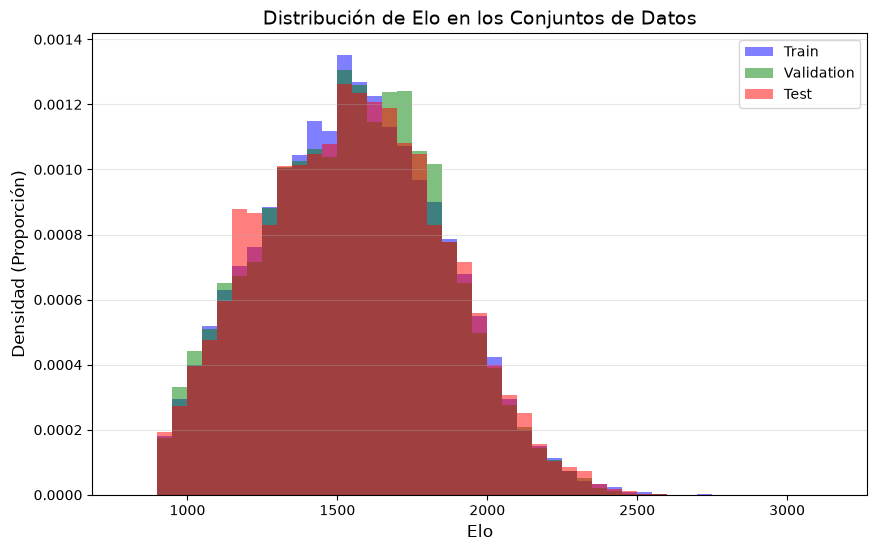

In [39]:
print("Generando histograma...")

plt.figure(figsize=(10, 6))

# Dibujamos los 3 histogramas. 
# alpha = transparencia para ver si se solapan.
# density = True es CLAVE para que los ejes Y representen proporciones y sean comparables.
bins_compartidos = np.arange(800, 3200, 50) # Barras cada 50 puntos de Elo

plt.hist(train_elos, bins=bins_compartidos, alpha=0.5, density=True, label='Train', color='blue')
plt.hist(val_elos, bins=bins_compartidos, alpha=0.5, density=True, label='Validation', color='green')
plt.hist(test_elos, bins=bins_compartidos, alpha=0.5, density=True, label='Test', color='red')

plt.title('Distribución de Elo en los Conjuntos de Datos', fontsize=14)
plt.xlabel('Elo', fontsize=12)
plt.ylabel('Densidad (Proporción)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Guarda la imagen en tu escritorio para usarla en la tesis
ruta_imagen = "../data/generado/graficos/distribucion_elo_data.png"
plt.savefig(ruta_imagen, dpi=300, bbox_inches='tight')
print(f"✅ Histograma guardado en: {ruta_imagen}")

plt.show()